In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

/home/jn/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_excel('../papers.xlsx')
df.head()

,Paper Title,Citation ID,Publication Year,main cat,main cat 2,sub cat 1,sub cat 2,sub cat 3,sub cat 4
0,Friend or Foe: An Investigation Into Recipient...,clasen2021friend,2021,Characterization,User Susceptibility,Psychological Techniques,Demographic,NaN,NaN
1,Detecting and Characterizing SMS Spearphishing...,liu2021detecting,2021,Characterization,Defense & Tools,Attack Types,Natural Language Processing,NaN,NaN
2,SmishViz: Towards a Graph-Based Visualization ...,pritom_25_codaspy_smishviz,2025,Characterization,Detection,Attack Types,Attack Themes,NaN,NaN
3,Mobile Phishing Attacks and Mitigation Techniques,shahriar2015mobile,2015,Characterization,Defense & Tools,Attack Types,Mobile-Based Solutions,NaN,NaN
4,A Study on the Psychology of Social Engineerin...,siddiqi2022study,2022,Characterization,User Susceptibility,Psychological Techniques,Mobile-Based Solutions,NaN,NaN


In [3]:
df['main cat'] = df['main cat'].str.strip()
df['main cat 2'] = df['main cat 2'].str.strip()
df['sub cat 1'] = df['sub cat 1'].str.strip()
df['sub cat 2'] = df['sub cat 2'].str.strip()
df['sub cat 3'] = df['sub cat 3'].str.strip()
df['sub cat 4'] = df['sub cat 4'].str.strip()


df['main cat'] = df['main cat'].fillna('')
df['main cat 2'] = df['main cat 2'].fillna('')
df['sub cat 1'] = df['sub cat 1'].fillna('')
df['sub cat 2'] = df['sub cat 2'].fillna('')
df['sub cat 3'] = df['sub cat 3'].fillna('')
df['sub cat 4'] = df['sub cat 4'].fillna('')

df['Citation ID'] = df['Citation ID'].fillna('')


In [4]:
df['Publication Year'].value_counts()

Publication Year
2024    37
2023    22
2022    12
2025    10
2021     8
2020     6
2018     4
2015     3
2017     3
2019     3
2006     2
2011     2
2013     1
2012     1
2016     1
2014     1
Name: count, dtype: int64

In [5]:
min(df['Publication Year']), max(df['Publication Year'])

(2006, 2025)

In [6]:
df['main cat'] = df['main cat'].replace('Defense & Tools', 'Tools and Mobile Apps')
df['main cat 2'] = df['main cat 2'].replace('Defense & Tools', 'Tools and Mobile Apps')

In [7]:
df['main cat'].value_counts()

main cat
Detection                61
User Susceptibility      19
Characterization         17
Tools and Mobile Apps    10
User training             5
Datasets                  4
Name: count, dtype: int64

In [8]:
df['main cat 2'].value_counts()

main cat 2
                         90
Tools and Mobile Apps     9
User Susceptibility       6
Datasets                  6
User training             3
Detection                 1
Characterization          1
Name: count, dtype: int64

In [9]:
df[(df['main cat']=='Datasets')]

,Paper Title,Citation ID,Publication Year,main cat,main cat 2,sub cat 1,sub cat 2,sub cat 3,sub cat 4
13,On SMS Phishing Tactics and Infrastructure,on_phishing_tactics_nahapetyan2023sms,2024,Datasets,Characterization,Public Datasets,Attack Types,,
14,SMS Phishing Dataset for Machine Learning and ...,mishra2022sms_mendeley,2022,Datasets,,Public Datasets,,,
15,Creating a Live Public Short Message Service ...,nus_chen2013creating,2013,Datasets,,Public Datasets,,,
16,Smishing Dataset I: Phishing SMS Dataset from ...,timko2024smishing,2024,Datasets,Tools and Mobile Apps,Mobile-Based Solutions,,,


In [10]:
df[(df['main cat 2']=='Datasets')]

,Paper Title,Citation ID,Publication Year,main cat,main cat 2,sub cat 1,sub cat 2,sub cat 3,sub cat 4
5,Clues in Tweets: Twitter-Guided Discovery and ...,twitter-clues-ccs2022-spam,2022,Characterization,Datasets,Public Datasets,Attack Types,,
44,SMS Scam Detection Application Based on Optica...,shinde2024sms,2024,Detection,Datasets,Private Dataset,Machine Learning,Natural Language Processing,
45,A Persuasion-Based Prompt Learning Approach to...,llm_shim2024persuasion,2024,Detection,Datasets,Public Datasets,Natural Language Processing,,
49,KorSmishing Explainer: A Korean-Centric LLM-Ba...,expl_lee2024korsmishing,2024,Detection,Datasets,Natural Language Processing,Private Dataset,,
61,Contributions to the Study of SMS Spam Filteri...,UCI_sms_dataset,2011,Detection,Datasets,Public Datasets,Machine Learning,,
62,Investigating Evasive Techniques in SMS Spam F...,salman2024investigating,2024,Detection,Datasets,Public Datasets,Machine Learning,,


In [11]:
df['sub cat 1'].value_counts()

sub cat 1
Machine Learning                  33
General Susceptibility Factors    18
Attack Types                      10
Deep Learning                      9
Public Datasets                    7
Law Enforcement & Regulatory       7
Rule-Based                         5
Mobile-Based Solutions             5
Third-Party Tools                  4
Federated Learning                 3
Natural Language Processing        3
Psychological Techniques           3
Demographic                        2
User Training & Awareness          1
Attack Themes                      1
Private Dataset                    1
Explainable AI                     1
Mobile-Based                       1
Hybrid                             1
                                   1
Name: count, dtype: int64

In [12]:
plot_dict = {'2006-13':{}, '2014-17':{}, '2018':{}, '2019':{}, '2020':{}, '2021':{}, '2022':{}, '2023':{}, '2024':{}, '2025':{}}

for i in range(len(df)):
    year = df['Publication Year'][i]
    if year<2014:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2006-13']:
                plot_dict['2006-13'][df['main cat'][i]] += 1
            else:
                plot_dict['2006-13'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2006-13']:
                plot_dict['2006-13'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2006-13'][df['main cat 2'][i]] = 1
    
    elif year>2013 and year<2018:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2014-17']:
                plot_dict['2014-17'][df['main cat'][i]] += 1
            else:
                plot_dict['2014-17'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2014-17']:
                plot_dict['2014-17'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2014-17'][df['main cat 2'][i]] = 1
    

    elif year==2018:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2018']:
                plot_dict['2018'][df['main cat'][i]] += 1
            else:
                plot_dict['2018'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2018']:
                plot_dict['2018'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2018'][df['main cat 2'][i]] = 1

    

    elif year==2019:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2019']:
                plot_dict['2019'][df['main cat'][i]] += 1
            else:
                plot_dict['2019'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2019']:
                plot_dict['2019'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2019'][df['main cat 2'][i]] = 1


    
    elif year==2020:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2020']:
                plot_dict['2020'][df['main cat'][i]] += 1
            else:
                plot_dict['2020'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2020']:
                plot_dict['2020'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2020'][df['main cat 2'][i]] = 1

    elif year==2021:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2021']:
                plot_dict['2021'][df['main cat'][i]] += 1
            else:
                plot_dict['2021'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2021']:
                plot_dict['2021'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2021'][df['main cat 2'][i]] = 1

    
    elif year==2022:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2022']:
                plot_dict['2022'][df['main cat'][i]] += 1
            else:
                plot_dict['2022'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2022']:
                plot_dict['2022'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2022'][df['main cat 2'][i]] = 1
    

    elif year==2023:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2023']:
                plot_dict['2023'][df['main cat'][i]] += 1
            else:
                plot_dict['2023'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2023']:
                plot_dict['2023'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2023'][df['main cat 2'][i]] = 1
    

    elif year==2024:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2024']:
                plot_dict['2024'][df['main cat'][i]] += 1
            else:
                plot_dict['2024'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2024']:
                plot_dict['2024'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2024'][df['main cat 2'][i]] = 1
    

    elif year==2025:
        if df['main cat'][i]:
            if df['main cat'][i] in plot_dict['2025']:
                plot_dict['2025'][df['main cat'][i]] += 1
            else:
                plot_dict['2025'][df['main cat'][i]] = 1
        
        if df['main cat 2'][i]:
            if df['main cat 2'][i] in plot_dict['2025']:
                plot_dict['2025'][df['main cat 2'][i]] += 1
            else:
                plot_dict['2025'][df['main cat 2'][i]] = 1

In [13]:
for i in plot_dict:
    for j in plot_dict[i]:
        print(j, end=', ')
    print()

Datasets, Tools and Mobile Apps, Detection, 
Characterization, Tools and Mobile Apps, User Susceptibility, Detection, 
Detection, 
Detection, Tools and Mobile Apps, 
Characterization, User Susceptibility, Detection, User training, 
Characterization, User Susceptibility, Tools and Mobile Apps, Detection, 
Characterization, User Susceptibility, Datasets, Tools and Mobile Apps, Detection, 
Characterization, Tools and Mobile Apps, Detection, User Susceptibility, User training, 
Characterization, Datasets, Tools and Mobile Apps, User training, Detection, User Susceptibility, 
Characterization, Detection, User Susceptibility, User training, 


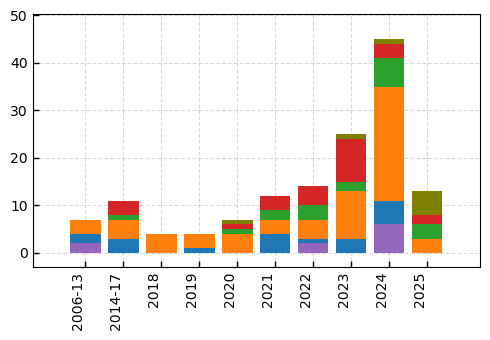

In [14]:
df_plot = pd.DataFrame.from_dict(plot_dict, orient='index').fillna(0)


custom_year_order = [
    '2006-13',
    '2014-17',
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]


df_plot = df_plot.reindex(index=custom_year_order, fill_value=0)

time_periods = df_plot.index.tolist()

# Plotting
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', length=4, width=1)

bottom = [0] * len(time_periods)


colors = {'Tools and Mobile Apps': '#1f77b4', 'Detection': '#ff7f0e', 'Characterization': '#2ca02c', 'Datasets': '#9467bd', 'User Susceptibility': '#d62728', 'User training':'olive'}

# Iterate through categories to stack bars with custom colors
for category in df_plot.columns:
    current_color = colors.get(category, 'gray') # Get color, default to 'gray' if not found
    ax.bar(time_periods, df_plot[category], label=category, bottom=bottom, color=current_color)
    # Update bottom for the next stack
    bottom = [b + val for b, val in zip(bottom, df_plot[category])]

# Moved axis limit adjustments here
x_min_orig, x_max_orig = ax.get_xlim()
y_min_orig, y_max_orig = ax.get_ylim()

padding_bottom = 3.0
padding_left = 0.5
padding_right = 0.5

ax.set_ylim(bottom=y_min_orig - padding_bottom, top=y_max_orig + padding_bottom)
ax.set_xlim(left=x_min_orig - padding_left, right=x_max_orig + padding_right)

# ax.legend(title='Category', loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
# Show the plot
plt.show()

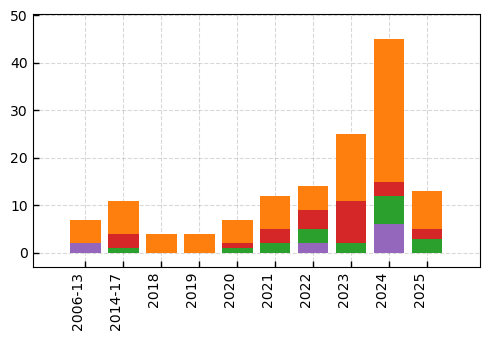

In [15]:
df_plot = pd.DataFrame.from_dict(plot_dict, orient='index').fillna(0)

custom_year_order = [
    '2006-13',
    '2014-17',
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]

df_plot = df_plot.reindex(index=custom_year_order, fill_value=0)

time_periods = df_plot.index.tolist()

# Plotting
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', length=4, width=1)

bottom = [0] * len(time_periods)

colors = {'Tools and Mobile Apps': '#1f77b4', 'Detection': '#ff7f0e', 'Characterization': '#2ca02c', 'Datasets': '#9467bd', 'User Susceptibility': '#d62728', 'User training':'olive'}

# Define categories that fall under 'Defense Landscape'
defense_categories = ['Tools and Mobile Apps', 'Detection', 'User training']

# Choose a single common color for all defense categories
# Using the original color of 'Tools and Mobile Apps' as the common defense color
common_defense_color = colors['Detection']


# Separate independent categories from defense categories
independent_categories = [col for col in df_plot.columns if col not in defense_categories]

# Define the order in which categories should be plotted for stacking
# Independent categories first, then defense categories (to group them visually)
plotting_order = independent_categories + defense_categories


# Iterate through categories based on the defined plotting_order
for category in plotting_order:
    current_color = colors.get(category, 'gray') # Get default color for non-defense categories

    # If the category is a defense category, override its color with the common defense color
    if category in defense_categories:
        current_color = common_defense_color

    ax.bar(time_periods, df_plot[category], label=category, bottom=bottom, color=current_color)
    # Update bottom for the next stack
    bottom = [b + val for b, val in zip(bottom, df_plot[category])]

# Moved axis limit adjustments here
x_min_orig, x_max_orig = ax.get_xlim()
y_min_orig, y_max_orig = ax.get_ylim()

padding_bottom = 3.0
padding_left = 0.5
padding_right = 0.5

ax.set_ylim(bottom=y_min_orig - padding_bottom, top=y_max_orig + padding_bottom)
ax.set_xlim(left=x_min_orig - padding_left, right=x_max_orig + padding_right)

# Add the legend. Matplotlib will automatically use the assigned colors for each label.
# ax.legend(title='Category', loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

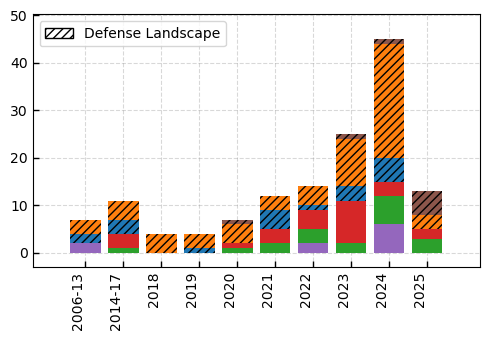

In [16]:
df_plot = pd.DataFrame.from_dict(plot_dict, orient='index').fillna(0)

custom_year_order = [
    '2006-13',
    '2014-17',
    '2018',
    '2019',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]

df_plot = df_plot.reindex(index=custom_year_order, fill_value=0)

time_periods = df_plot.index.tolist()

# Plotting
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', length=4, width=1)

bottom = [0] * len(time_periods)

colors = {'Tools and Mobile Apps': '#1f77b4', 'Detection': '#ff7f0e', 'Characterization': '#2ca02c', 'Datasets': '#9467bd', 'User Susceptibility': '#d62728', 'User training':'#8c564b'}

# Define categories that fall under 'Defense Landscape'
defense_categories = ['Tools and Mobile Apps', 'Detection', 'User training']

# Separate independent categories from defense categories
independent_categories = [col for col in df_plot.columns if col not in defense_categories]

# Define the order in which categories should be plotted for stacking
# Here, independent categories are plotted first, then defense categories
plotting_order = independent_categories + defense_categories


# Initialize legend handles and labels, now only for 'Defense Landscape'
legend_handles = []
legend_labels = []
defense_landscape_added_to_legend = False

# Iterate through categories based on the new plotting_order
for category in plotting_order:
    current_color = colors.get(category, 'gray')
    hatch_pattern = '////' if category in defense_categories else None # Using 'xxxx' for denser stripes

    # Plot the bar
    ax.bar(time_periods, df_plot[category], bottom=bottom, color=current_color, hatch=hatch_pattern)

    # Update bottom for the next stack
    bottom = [b + val for b, val in zip(bottom, df_plot[category])]

    # Only add the 'Defense Landscape' proxy to the legend once
    if category in defense_categories and not defense_landscape_added_to_legend:
        # Set facecolor to 'none' to make the patch transparent, showing only stripes
        legend_handles.append(mpatches.Patch(facecolor='none', hatch='////', edgecolor='black')) # Ensure hatch matches
        legend_labels.append('Defense Landscape')
        defense_landscape_added_to_legend = True

# Moved axis limit adjustments here
x_min_orig, x_max_orig = ax.get_xlim()
y_min_orig, y_max_orig = ax.get_ylim()

padding_bottom = 3.0
padding_left = 0.5
padding_right = 0.5

ax.set_ylim(bottom=y_min_orig - padding_bottom, top=y_max_orig + padding_bottom)
ax.set_xlim(left=x_min_orig - padding_left, right=x_max_orig + padding_right)

# Add the legend using only the 'Defense Landscape' handles and labels
ax.legend(handles=legend_handles, labels=legend_labels, title='', loc='best') # 'best' typically finds a good spot

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3, color='gray')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

Citation generation bibtex style

In [17]:
selected_cat_citation = {}
for i in list(df['main cat'].value_counts().keys()):
    selected_cat_citation[i] = []
selected_cat_citation

{'Detection': [],
 'User Susceptibility': [],
 'Characterization': [],
 'Tools and Mobile Apps': [],
 'User training': [],
 'Datasets': []}

In [18]:
#a paper can have multiple categories like dataset + detection

for i in range(len(df)):
    if df['main cat'][i] and df['Citation ID'][i]:
        selected_cat_citation[df['main cat'][i]].append(df['Citation ID'][i])
    if df['main cat 2'][i] and df['Citation ID'][i]:
        selected_cat_citation[df['main cat 2'][i]].append(df['Citation ID'][i])

In [19]:
for i in selected_cat_citation:
    print(len(selected_cat_citation[i]))

62
25
18
19
8
10


In [20]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Detection'][1:] + '}{\\color[HTML]{' + colors['Detection'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{Detection ('+str(len(selected_cat_citation['Detection']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Detection']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{ff7f0e}{\\color[HTML]{ff7f0e}\\rule{0.1cm}{0.1cm}}} \\textbf{Detection (62 papers)} \\cite{pritom_25_codaspy_smishviz, mishra2019content, ghourabi2020hybrid, sonowal2020detecting, smdetector_ghourabi, njuguna2021model, ulfath2022detecting, spam_filtering_cnn_lstm_hossain, smsprotect_akande, karhani_phishing_2023, dsmish_mishra_2023, shanto2023federated, sidhpura2023_fedspam:, seo2024device, anh2024federated, hapase2024telecommunication, rose2024next_federated, mehmood2024enhancing, shinde2024sms, llm_shim2024persuasion, uddin2024explainabledetector, wangcan, samad2023smishguard, expl_lee2024korsmishing, vats2024federated, mahmud2024enhancing, NIPS2017_SHAP, ribeiro2016should, shendkar2024enhancing, mohite2024interpretable, kohilan2023machine, goel2024machine, chithambaramani2024sms, enron_vangelis2006spam, british_sms_dataset2011, UCI_sms_dataset, salman2024investigating, kor_smsphishing_info15050265, jain2019feature, mishra2019mit, vats2024federated

In [21]:
len(selected_cat_citation['Detection'])

62

In [22]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Tools and Mobile Apps'][1:] + '}{\\color[HTML]{' + colors['Tools and Mobile Apps'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{Tools \& Mobile Apps ('+str(len(selected_cat_citation['Tools and Mobile Apps']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Tools and Mobile Apps']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{1f77b4}{\\color[HTML]{1f77b4}\\rule{0.1cm}{0.1cm}}} \\textbf{Tools \\& Mobile Apps (19 papers)} \\cite{liu2021detecting, shahriar2015mobile, timko2024smishing, commerial_anti_smishing_timko_2023, virus-total, phishtank, siadati2017mind, blancaflor2021let, wang2024verisms, zielinski2024evolving_law, bappy2024conchain_attackresilient, 2022blockchain_csm_mir_xu, sajid_2021_soda, njuguna2021model, smsprotect_akande, mishra2019mit, aleroud2017phishing, kanaoka2023beyond, al2024advancements}'

In [23]:
len(selected_cat_citation['Tools and Mobile Apps'])

19

In [24]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['User Susceptibility'][1:] + '}{\\color[HTML]{' + colors['User Susceptibility'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{User Susceptibility ('+str(len(selected_cat_citation['User Susceptibility']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['User Susceptibility']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{d62728}{\\color[HTML]{d62728}\\rule{0.1cm}{0.1cm}}} \\textbf{User Susceptibility (25 papers)} \\cite{clasen2021friend, siddiqi2022study, alabdan2020phishing, siadati2017mind, blancaflor2021let, kumarasinghe2023user, lutfor_23_codaspy_users_smished, sarno2024gets_users, yeboah2014phishing, ribeiro2024factors, tabassum2024drives_uncc, edwards2023smishing, blancaflor2023case, sugunaraj2022cyber_laws, katsarakes2024users, yan2021awareness, faklaris2023preliminary, timko2023quantitative, timkounderstanding, yoro2023evidence, bach2022targets, multi_modal_neupane, yoro2023assessing, ic3, Longtchi_2025_Phsychological_tactics}'

In [25]:
len(selected_cat_citation['User Susceptibility'])

25

In [26]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Datasets'][1:] + '}{\\color[HTML]{' + colors['Datasets'][1:] + '}\\rule{0.1cm}{0.1cm}}}  \\textbf{Datasets('+str(len(selected_cat_citation['Datasets']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Datasets']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{9467bd}{\\color[HTML]{9467bd}\\rule{0.1cm}{0.1cm}}}  \\textbf{Datasets(10 papers)} \\cite{twitter-clues-ccs2022-spam, on_phishing_tactics_nahapetyan2023sms, mishra2022sms_mendeley, nus_chen2013creating, timko2024smishing, shinde2024sms, llm_shim2024persuasion, expl_lee2024korsmishing, UCI_sms_dataset, salman2024investigating}'

In [27]:
len(selected_cat_citation['Datasets'])

10

In [28]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['Characterization'][1:] + '}{\\color[HTML]{' + colors['Characterization'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{Attack Characterization('+str(len(selected_cat_citation['Characterization']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['Characterization']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{2ca02c}{\\color[HTML]{2ca02c}\\rule{0.1cm}{0.1cm}}} \\textbf{Attack Characterization(18 papers)} \\cite{clasen2021friend, liu2021detecting, pritom_25_codaspy_smishviz, shahriar2015mobile, siddiqi2022study, twitter-clues-ccs2022-spam, ahnlab2023, apwg_phishing_trend2024, FTC_loss_stat, shibli2024abusegpt, alabdan2020phishing, nahapetyanposter_2023, XuPIEEE2024, on_phishing_tactics_nahapetyan2023sms, montanez2022cyberkillchain, Longtchi_2025_Phsychological_tactics, montanez2024Quantifying, FTC_latest_report_2025}'

In [29]:
len(selected_cat_citation['Characterization'])

18

In [30]:
'\\raisebox{0.4ex}{\\colorbox[HTML]{' + colors['User training'][1:] + '}{\\color[HTML]{' + colors['User training'][1:] + '}\\rule{0.1cm}{0.1cm}}} \\textbf{User Training and Regulation('+str(len(selected_cat_citation['User training']))+' papers)} \\cite{' + ', '.join(selected_cat_citation['User training']) + '}'

'\\raisebox{0.4ex}{\\colorbox[HTML]{8c564b}{\\color[HTML]{8c564b}\\rule{0.1cm}{0.1cm}}} \\textbf{User Training and Regulation(8 papers)} \\cite{zielinski2024evolving_law, faklaris2023preliminary, gdpr-walker, idtexpressDataPrivacy, yotpoNeedKnow, gdprlocalEssentialGuide, caCCPAEnforcement, FTC_latest_report_2025}'

In [31]:
len(selected_cat_citation['User training'])

8